In [ ]:
import numpy as np

# Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0
arr3=np.ones((5,5))
arr3[1:4,1:4]=0
print(arr3)

# Task 2: Normalize a random array
np.random.seed(42)
random_data = np.random.randn(100, 3)
normalised = (random_data-random_data.mean(axis=0))/random_data.std(axis=0)

willie=normalised.mean(axis=0)
willie1=normalised.std(axis=0)

print(f'Mean of the column: {willie}')

print(f'The std of each coulumn {willie1}')


# Task 3: Implement linear regression solution using normal equation

X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

theta_hat=np.linalg.inv(X.T @ X)@X.T@y

print(f'Estimate: {theta_hat}')
print(f'True: {true_theta}')




[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
Mean of the column: [-2.60902411e-17  1.55431223e-17 -8.88178420e-18]
The std of each coulumn [1. 1. 1.]
Estimate: [ 2.51723721 -1.19783796  3.72399266]
True: [ 2.5 -1.2  3.7]


In [34]:
#task 1
import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math',
      'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

print(df.describe())
print(df.info())

sk=df.isnull().sum()
print(f'The missing values: {sk}')


df['exam_score']= df.groupby('major')['exam_score'].transform(lambda x:x.fillna(x.mean()))


print(df.isnull().sum())



#task 2
mh= df.groupby('major')['exam_score'].mean()

qw = mh.sort_values(ascending=False)
high=qw.index[0]
print(f'Highest average: {high}')

bola= df['hours_studied'].corr(df['exam_score'])
print(f'The correlation is {bola}')


def theperformance(score):
  if score > 90:
    return 'Excellet'
  elif score>= 80:
    return 'Good'
  elif score>=70:
    return 'Average'
  else:
    return 'Need Inprovement'
df['performance']=df['exam_score'].apply(theperformance)



#Task 3
opop= df.groupby(['major', 'year'])[['exam_score', 'hours_studied']].agg(['count', 'mean'])
print(opop)

students5= df.sort_values('exam_score', ascending=False).head(5)
print(students5)


outofvariables= df.groupby(['major', 'year'])['exam_score'].mean().unstack()
print(outofvariables)


        student_id        year  exam_score  assignments_completed  \
count   200.000000  200.000000  190.000000             200.000000   
mean   1099.500000    2.615000   75.510638               4.700000   
std      57.879185    1.159091    9.582797               3.239207   
min    1000.000000    1.000000   42.587327               0.000000   
25%    1049.750000    2.000000   68.206910               2.000000   
50%    1099.500000    3.000000   75.728033               4.000000   
75%    1149.250000    4.000000   81.813642               8.000000   
max    1199.000000    4.000000  100.000000              10.000000   

       hours_studied  
count     195.000000  
mean       14.776761  
std         5.251905  
min         1.295226  
25%        11.637963  
50%        14.575456  
75%        18.345691  
max        28.918887  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------    

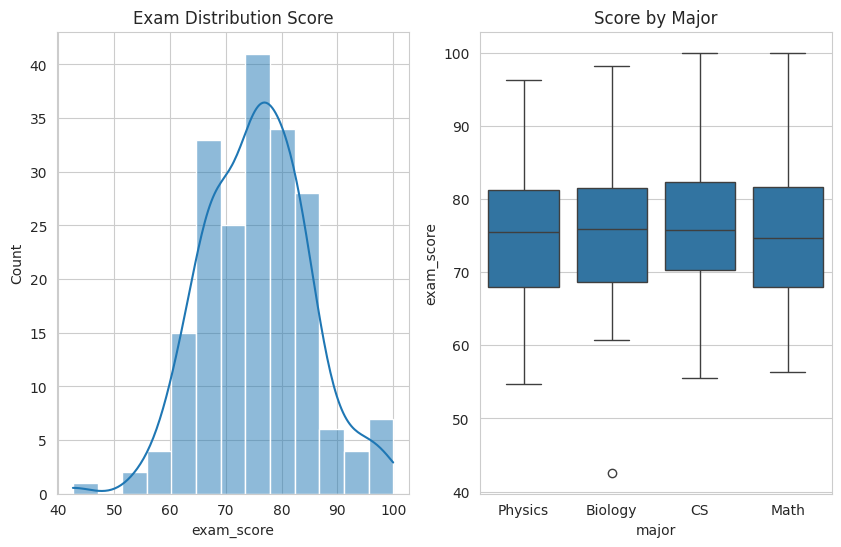

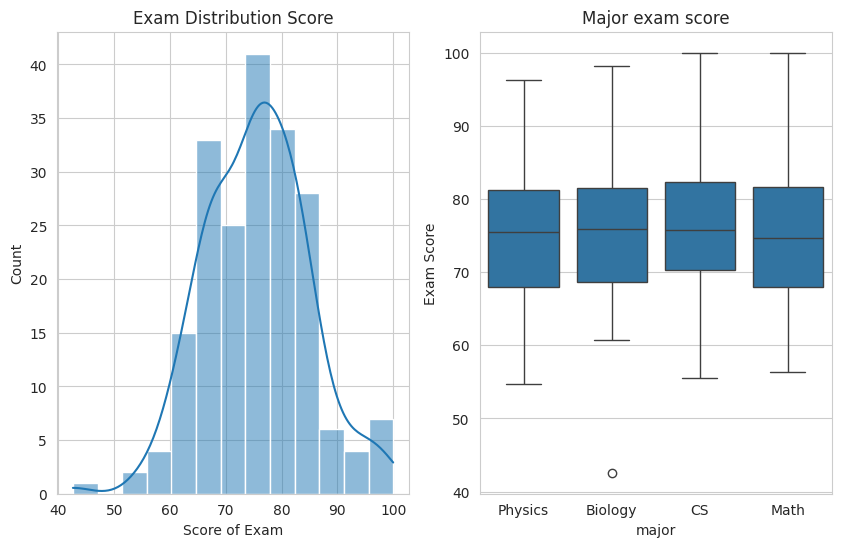

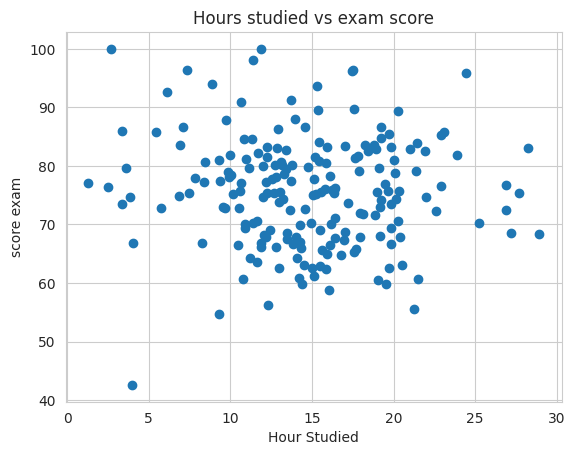

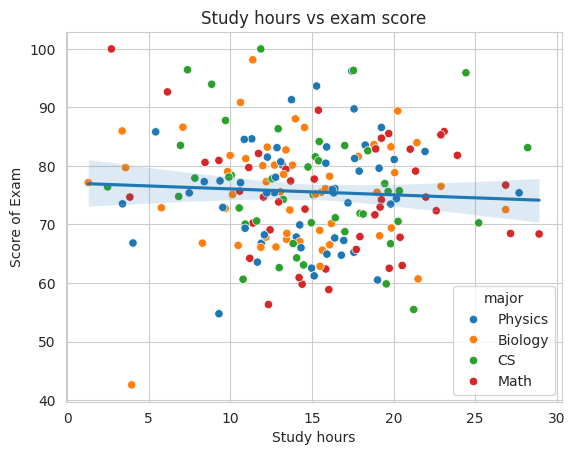

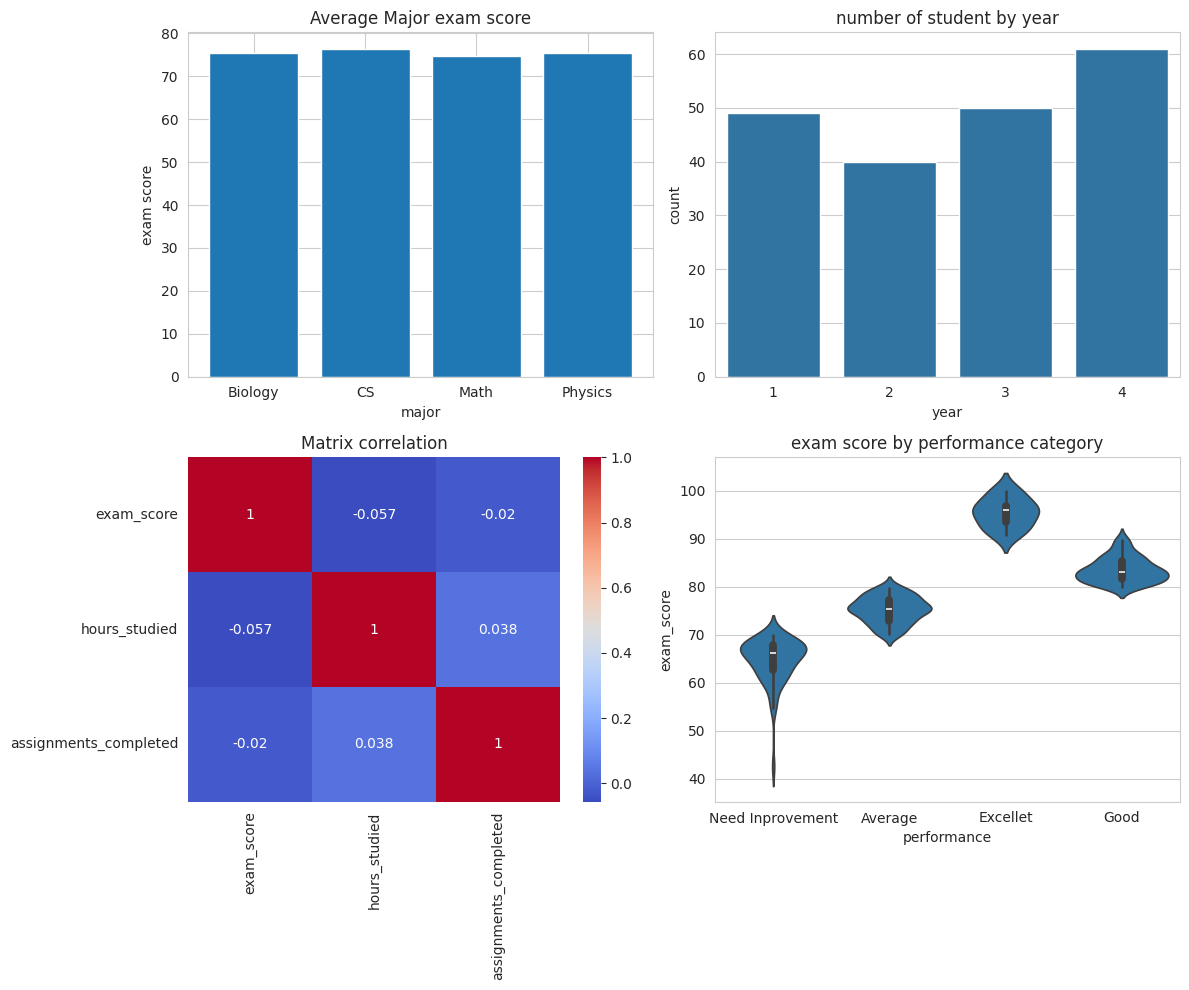

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

#Task 1
fig, (bono, bini)= plt.subplots(1,2, figsize=(10,6))

sns.histplot(data=df,x='exam_score', kde=True, ax=bono)
bono.set_title('Exam Distribution Score')


sns.boxplot(data=df, x='major', y='exam_score', ax=bini)
bini.set_title('Score by Major')

plt.show()


sns.set_style('whitegrid')

fig,(bobo, bibi)= plt.subplots(1,2, figsize= (10,6))

sns.histplot(data=df, x='exam_score', kde=True, ax=bobo)
bobo.set_title('Exam Distribution Score')
bobo.set_xlabel('Score of Exam')
bobo.set_ylabel('Count')


sns.boxplot(data=df, x='major', y='exam_score', ax=bibi)
bibi.set_title('Major exam score')
bibi.set_xlabel('major')
bibi.set_ylabel('Exam Score')

plt.show()



#task 2
plt.scatter(df['hours_studied'], df['exam_score'])
plt.xlabel('Hour Studied')
plt.ylabel('score exam')
plt.title('Hours studied vs exam score')
plt.show()



sns.scatterplot(data=df, x='hours_studied', y='exam_score', hue= 'major')

sns.regplot(data=df, x='hours_studied', y='exam_score', scatter=False)

plt.title('Study hours vs exam score')
plt.xlabel('Study hours')
plt.ylabel('Score of Exam')
plt.show()



#task 3
fig,((bobo, bibi), (banku, binku))= plt.subplots(2,2, figsize=(12, 10))
saka=df.groupby('major')['exam_score'].mean()
bobo.bar(saka.index,saka.values)
bobo.set_title('Average Major exam score')
bobo.set_xlabel('major')
bobo.set_ylabel('exam score')


sns.countplot(data=df, x='year', ax=bibi)
bibi.set_title('number of student by year')

papa=df[['exam_score', 'hours_studied', 'assignments_completed']].corr()
sns.heatmap(papa, annot=True,cmap='coolwarm', ax=banku)
banku.set_title('Matrix correlation')


sns.violinplot(data=df, x= 'performance', y='exam_score', ax=binku)
binku.set_title('exam score by performance category')

plt.tight_layout()
plt.show()

   age        income  purchase_frequency  avg_purchase_value  churn_risk  \
0   56  92443.123940                   7           94.527456    0.416667   
1   69  70649.305211                   2          100.932279    0.833333   
2   46  19612.600681                   3           79.699876    0.750000   
3   32  40315.318543                   2          130.137787    0.833333   
4   60  75338.222984                   8          102.904845    0.333333   

           CLV  
0   937.397271  
1   370.085023  
2   418.424348  
3   477.171887  
4  1097.651683  
           no0fpeople  incomeavegrage        otoo          adele
age_group                                                       
18.-25             81    50634.018330  718.371170   58188.064760
26-35              73    48747.148046  747.738562   54584.915035
36-50             160    48516.895668  732.796612  117247.457917
51-70             186    50713.163384  762.693498  141860.990683
     age        income  purchase_frequency  avg_pur

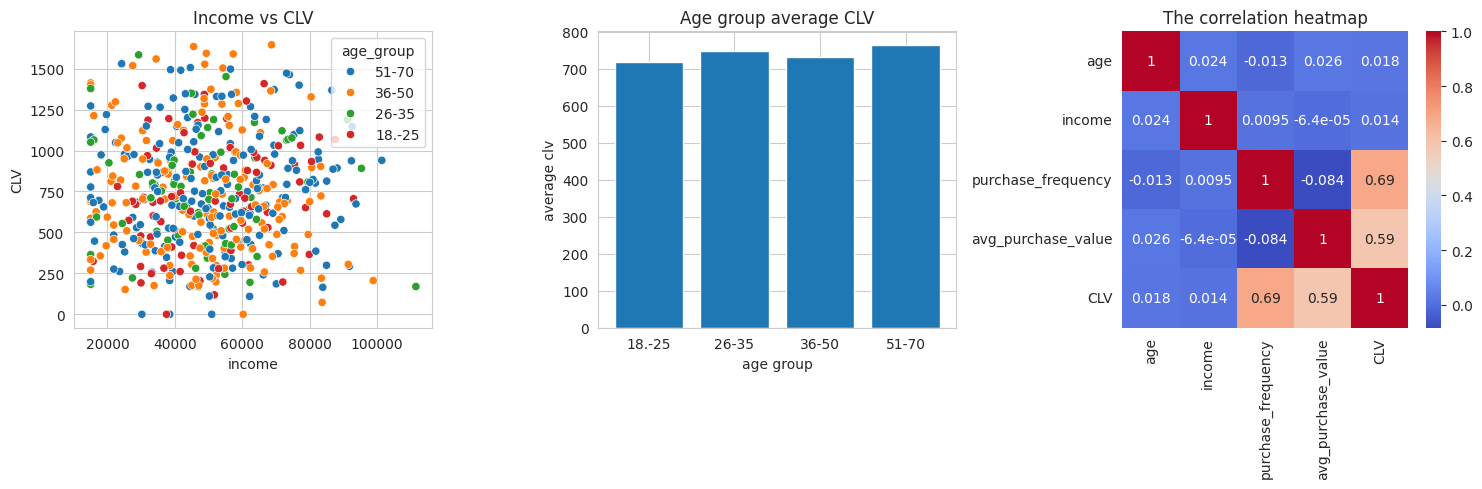

In [30]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""

# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

#task 1
themost = customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / themost)
customers['CLV'] = customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + customers['churn_risk'])
suii=customers.head()
print(suii)


def bingo(age):
  if age<=25:
    return '18-25'
  elif age<=35:
    return '26-35'
  elif age<=50:
    return '36-50'
  else:
    return '51-70'
customers['age_group']=customers['age'].apply(bingo)


tommy=customers.groupby('age_group').agg(
    no0fpeople=('age', 'count'), incomeavegrage=('income','mean'), otoo=('CLV', 'mean'), adele=('CLV', 'sum')
)
print(tommy)

number1=customers.sort_values('CLV', ascending=False).head(int(len(customers )*0.1))
print(number1)



fig, (bono, bini, banku)=plt.subplots(1,3, figsize=(15,5))
sns.scatterplot(data=customers, x='income', y='CLV', hue='age_group', ax=bono)
bono.set_title('Income vs CLV')


pone=customers.groupby('age_group')['CLV'].mean()
bini.bar(pone.index,pone.values)
bini.set_title('Age group average CLV')
bini.set_xlabel('age group')
bini.set_ylabel('average clv')


amp=customers[['age', 'income', 'purchase_frequency', 'avg_purchase_value', 'CLV']].corr()
sns.heatmap(amp,annot=True, cmap='coolwarm', ax=banku)
banku.set_title('The correlation heatmap')

plt.tight_layout()
plt.show()


the age and income of customers do not really matter, the customers who buy and usually spend more are the most valuable.

recommendation:
get customers to buy more often
prevent the customers from leaving

